Para esta notebook se usan los Datos Históricos de **Precipitación** de la **Estación 232 - Pilar**

Fuente: https://snih.hidricosargentina.gob.ar

In [ ]:
# Importo librerias necesarias
import pandas as pd
import matplotlib.pyplot as plt

## Importación de dataset

In [ ]:
url = "https://raw.githubusercontent.com/YasminMondinoLl/SeriesTemporales_2026/main/Precipitacion-Estacion232.xlsx"

datos_precipitacion = pd.read_excel(url, header = 1)


In [ ]:
datos_precipitacion["Fecha y Hora"] = pd.to_datetime(datos_precipitacion["Fecha y Hora"],
                                       dayfirst = True)                                             # Indicamos tipo de dato fecha y hora

datos_precipitacion= datos_precipitacion.rename(columns={"Precipitación [mm]": "Precipitacion"})    # Acortamos el nombre para simplificar

datos_precipitacion.head()

,Fecha y Hora,Precipitacion
0,2019-06-30 11:00:00,0.0
1,2019-06-30 11:10:00,0.0
2,2019-06-30 11:20:00,0.0
3,2019-06-30 11:30:00,0.0
4,2019-06-30 11:40:00,0.0


In [ ]:
datos_precipitacion.tail()

,Fecha y Hora,Precipitacion
307456,2026-06-30 23:10:00,0.0
307457,2026-06-30 23:20:00,0.0
307458,2026-06-30 23:30:00,0.0
307459,2026-06-30 23:40:00,0.0
307460,2026-06-30 23:50:00,0.0


## Pre-procesamiento de datos

In [ ]:
print(f"El dataset tiene {datos_precipitacion.shape[0]} filas")

El dataset tiene 307461 filas


In [ ]:
duplicados = datos_precipitacion["Fecha y Hora"].duplicated().sum()
print(f'Hay {duplicados} fechas repetidas')

Hay 6581 fechas repetidas


In [ ]:
datos_precipitacion[datos_precipitacion["Fecha y Hora"].duplicated(keep=False)]

,Fecha y Hora,Precipitacion
6,2019-06-30 12:00:00,0.0
7,2019-06-30 12:00:00,0.0
13,2019-06-30 13:00:00,0.0
14,2019-06-30 13:00:00,0.0
20,2019-06-30 14:00:00,0.0
...,...,...
88072,2021-06-28 09:00:00,0.0
88215,2021-06-29 09:00:00,0.0
88216,2021-06-29 09:00:00,0.0
88360,2021-06-30 09:00:00,0.0


Queremos sólo valor por día por lo que no requerimos la información de horario de medición

In [ ]:
datos_precipitacion["Fecha"] = datos_precipitacion["Fecha y Hora"].dt.normalize()

Como muchas fechas tienen más de un dato de precipitación, uso la siguiente función que agrupa los datos según la fecha y calcula la suma de los valores de precipitación para cada fecha. El reset_index es para volver a enumerar correctamente las filas de la tabla

In [ ]:
datos_precipitacion = datos_precipitacion.groupby("Fecha")["Precipitacion"].sum().reset_index()
datos_precipitacion

,Fecha,Precipitacion
0,2019-06-30,0.0
1,2019-07-01,0.0
2,2019-07-02,0.0
3,2019-07-03,0.0
4,2019-07-04,0.0
...,...,...
2161,2026-06-26,0.0
2162,2026-06-27,0.0
2163,2026-06-28,0.0
2164,2026-06-29,0.0


Analizo si hay fechas sin medición

In [ ]:
fechas_esperadas = pd.date_range(
                              start = datos_precipitacion["Fecha"].min(),
                              end = datos_precipitacion["Fecha"].max(),
                              freq = "D"
                          )

fechas_faltantes = fechas_esperadas.difference(datos_precipitacion["Fecha"])

print("Cantidad de días faltantes:", len(fechas_faltantes))
print(fechas_faltantes)

Cantidad de días faltantes: 392
DatetimeIndex(['2019-09-19', '2019-09-20', '2019-09-21', '2019-09-22',
               '2019-09-23', '2019-09-24', '2019-09-25', '2019-09-26',
               '2019-09-27', '2019-09-28',
               ...
               '2025-09-21', '2025-09-22', '2025-09-23', '2025-09-24',
               '2025-09-25', '2025-09-26', '2025-09-27', '2025-09-28',
               '2025-09-29', '2025-09-30'],
              dtype='datetime64[ns]', length=392, freq=None)


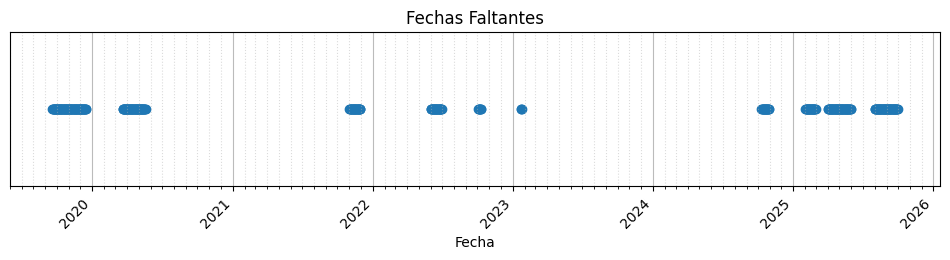

In [ ]:
import matplotlib.dates as mdates # Libreria que sirve para hacer el grid del plot más personalizable

fig, ax = plt.subplots(figsize=(12, 2))

ax.scatter(
            fechas_faltantes,
            [1] * len(fechas_faltantes)
        )

ax.set_yticks([])
ax.set_xlabel("Fecha")
ax.set_title("Fechas Faltantes")

ax.xaxis.set_major_locator(mdates.YearLocator(1))           # Permite hacer el grid cada 1 años
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))    # Pone el label del año

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1)) # Hace el grid cada 1 mes
ax.tick_params(axis="x", which="minor", labelbottom=False)  # Oculta el label, deja el tick

ax.grid(axis="x", which="major", alpha=0.85)                # Hace las lineas del grid para marcar los años
ax.grid(axis="x", which="minor", alpha=0.45, linestyle=":") # Hace las lineas del grid para marcar los meses, más suaves y punteadas

plt.xticks(rotation=45, ha='right')                         # Pone los valores del eje x en 45º
plt.show();

Puedo generar una tabla para analizar por año cuántos datos tengo y cuántos esperaría tener

In [ ]:
# Busco los valores minimo y maximo de las fechas del dataset
fecha_min = datos_precipitacion["Fecha"].min()
fecha_max = datos_precipitacion["Fecha"].max()

resumen = []
for año in range(fecha_min.year, fecha_max.year + 1):
    # Defino el inicio y el final del año
    inicio_año = pd.Timestamp(año, 1, 1)
    fin_año = pd.Timestamp(año, 12, 31)

    # Recortamos el año al rango real de datos (para el primer y último año porque el dataset no los cubre completos)
    inicio_esperado = max(inicio_año, fecha_min)
    fin_esperado = min(fin_año, fecha_max)

    # Con .days cuento los dias entre 2 fechas
    dias_esperados = (fin_esperado - inicio_esperado).days + 1

    # Cuento los dias del dataset que corresponden al año que estoy analizando
    dias_disponibles = datos_precipitacion[datos_precipitacion["Fecha"].dt.year == año]["Fecha"].nunique() #nunique es solo para asegurar que no cuenta fechas repetidas (aunque en nuestro caso no hay)

    resumen.append({
        "Año": año,
        "Días esperados": dias_esperados,
        "Días disponibles": dias_disponibles,
        "Días faltantes": dias_esperados - dias_disponibles,
        "% Informacion Disponible": 100 * dias_disponibles / dias_esperados
    })

resumen_df = pd.DataFrame(resumen)
resumen_df

,Año,Días esperados,Días disponibles,Días faltantes,% Informacion Disponible
0,2019,185,96,89,51.891892
1,2020,366,305,61,83.333333
2,2021,365,335,30,91.780822
3,2022,365,327,38,89.589041
4,2023,365,362,3,99.178082
5,2024,366,345,21,94.262295
6,2025,365,215,150,58.904110
7,2026,181,181,0,100.000000


Para los propósitos del notebook, todas las fechas faltantes se rellenan con valores interpolados

In [ ]:
datos_precipitacion_completo = (datos_precipitacion.set_index("Fecha")  # Usa temporalmente Fecha como índice
                      .reindex(fechas_esperadas)          # Reemplaza el índice por fechas_esperadas
                      .rename_axis("Fecha")               # Asigna el nombre "Fecha" al nuevo índice
                      .reset_index())                     # Convierte nuevamente el índice Fecha en una columna

datos_precipitacion_completo["Precipitacion"] = datos_precipitacion_completo["Precipitacion"].interpolate()

## Descomposición de la serie usando librerías

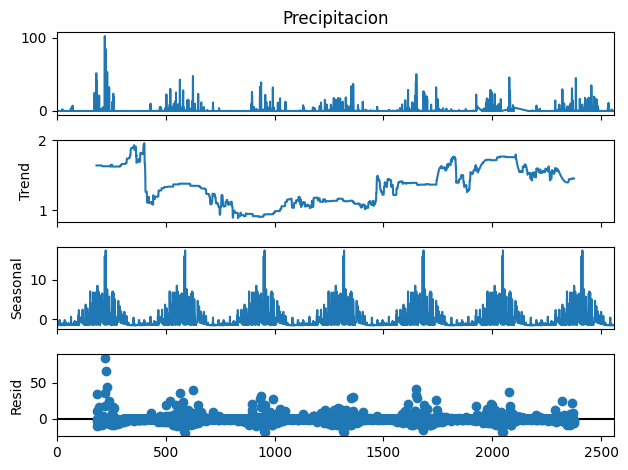

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

resultado = seasonal_decompose(
                            datos_precipitacion_completo["Precipitacion"],
                            model = "additive",
                            period = 365
                        )

resultado.plot()
plt.show()

Se puede acceder a cada componente por separado

In [ ]:
tendencia_libreria = resultado.trend
estacionalidad_libreria = resultado.seasonal
residuo_libreria = resultado.resid

La serie se considera la suma de los componentes:

Tendencia + Estacionalidad + Residuo

In [ ]:
reconstruida = tendencia_libreria + estacionalidad_libreria + residuo_libreria

Podemos graficar la serie reconstruida a partir de las componentes y la serie original proveniente de los datos

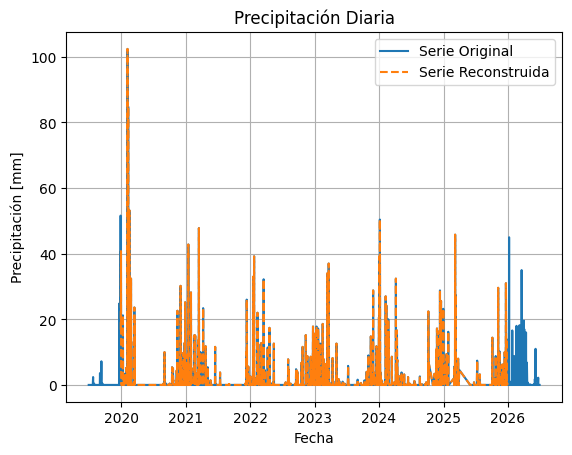

In [ ]:
plt.plot(datos_precipitacion_completo["Fecha"], datos_precipitacion_completo["Precipitacion"], label = 'Serie Original')
plt.plot(datos_precipitacion_completo["Fecha"], reconstruida, label = 'Serie Reconstruida',linestyle="--")


plt.xlabel("Fecha")
plt.ylabel("Precipitación [mm]")
plt.title("Precipitación Diaria")
plt.legend()
plt.grid()
plt.show();

## Descomposición Manual de la serie

**1) Estimación de Tendencia**

En esta notebook utilizamos un promedio móvil con periodo de 365 días, pero también podría hacerse con regresión lineal o ajustando un polinómio de mayor grado

In [ ]:
tendencia = datos_precipitacion_completo["Precipitacion"].rolling(
                      window=365,
                      center=True
                  ).mean()

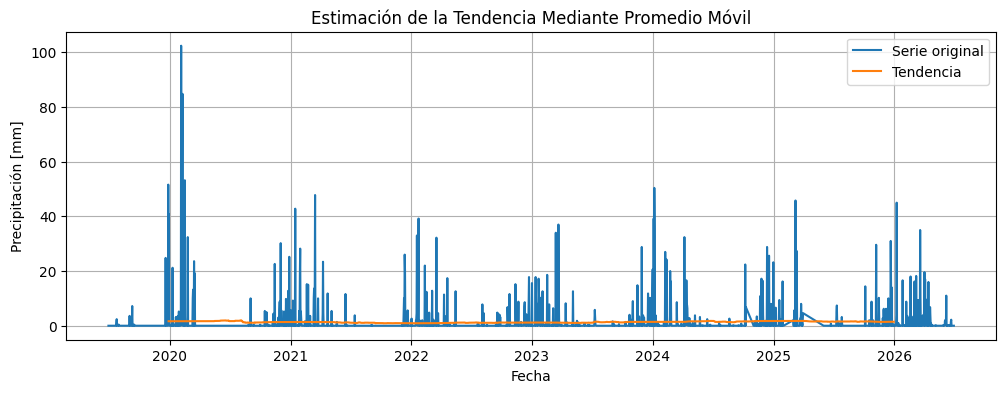

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(datos_precipitacion_completo["Fecha"], datos_precipitacion_completo["Precipitacion"], label="Serie original")
plt.plot(datos_precipitacion_completo["Fecha"], tendencia, label="Tendencia")

plt.xlabel("Fecha")
plt.ylabel("Precipitación [mm]")
plt.title("Estimación de la Tendencia Mediante Promedio Móvil")
plt.legend()
plt.grid()
plt.show();

**2) Quitamos la tendencia de la serie**

In [ ]:
datos_precipitacion_completo["Sin tendencia"] = datos_precipitacion_completo["Precipitacion"] - tendencia

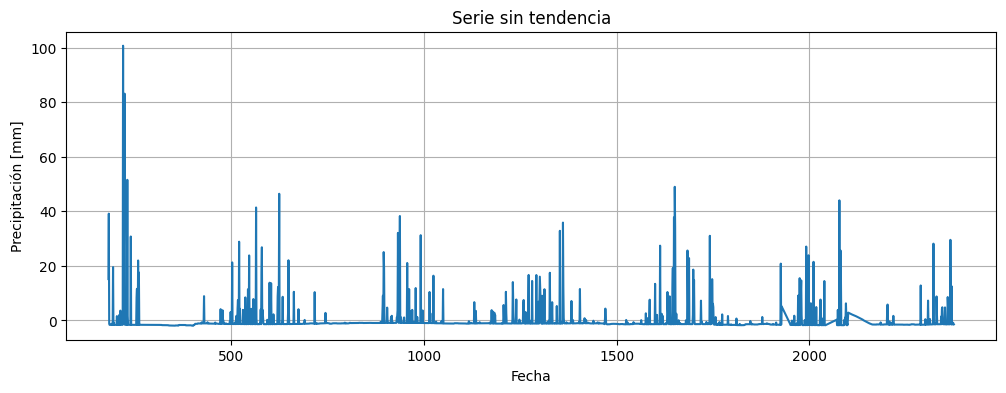

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(datos_precipitacion_completo["Sin tendencia"])

plt.xlabel("Fecha")
plt.ylabel("Precipitación [mm]")
plt.title("Serie sin tendencia")
plt.grid()
plt.show();

**3) Estimamos la Estacionalidad**

Calculamos la media de precipitación por día del año. Para ello agrupamos los datos por día del año y calculamos el valor medio de la Variable Sin Tendencia

In [ ]:
datos_precipitacion_completo["Dia_del_año"] = datos_precipitacion_completo["Fecha"].dt.dayofyear

precipitacion_anual = (
                  datos_precipitacion_completo.groupby("Dia_del_año")["Sin tendencia"].mean()
              )

precipitacion_anual.head()

,Sin tendencia
Dia_del_año,
1,4.908438
2,-0.924895
3,-0.424895
4,5.208438
5,-1.358228


Podemos graficar la Estacionalidad Promedio para los días del Año

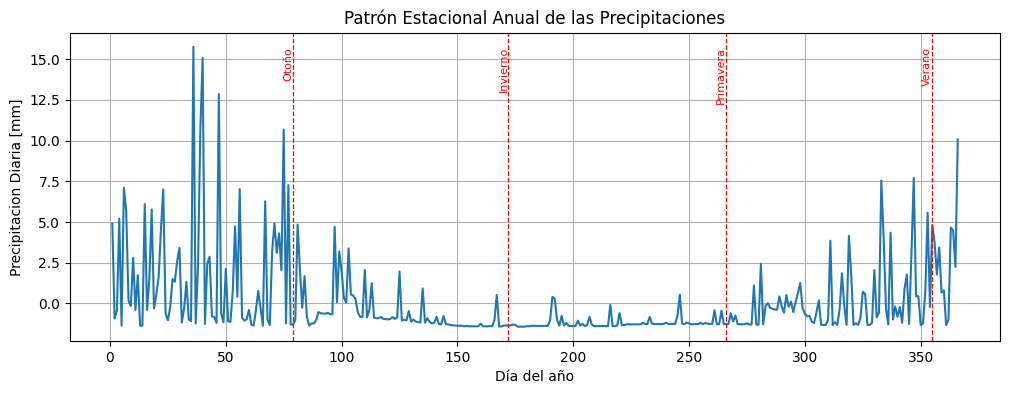

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(precipitacion_anual)

plt.xlabel("Día del año")
plt.ylabel("Precipitacion Diaria [mm]")
plt.title("Patrón Estacional Anual de las Precipitaciones")


inicios_estacion = {79: "Otoño", 172: "Invierno", 266: "Primavera", 355: "Verano"}

for dia, nombre in inicios_estacion.items():
    plt.axvline(x = dia, color = 'red', linestyle = '--', linewidth = 0.9)                                       # Agrego líneas para marcar los cambios de estación
    plt.text(dia, precipitacion_anual.max(), nombre, rotation=90, va="top", ha="right", color="red", fontsize=8) # Agrego el nombre de la estación a la que se cambia a la altura del maximo valor en y

plt.grid()
plt.show()

La función **map** de pandas nos permite reemplazar cada valor de una columna con los valor de otra serie

In [ ]:
# Tenemos la columna Día del Año
datos_precipitacion_completo["Dia_del_año"].head()

,Dia_del_año
0,181
1,182
2,183
3,184
4,185


In [ ]:
# Tenemos la serie que acabamos de hacer con el promedio de precipitacion diaria para cada día del año (sin tendencia)
precipitacion_anual.head()

,Sin tendencia
Dia_del_año,
1,4.908438
2,-0.924895
3,-0.424895
4,5.208438
5,-1.358228


In [ ]:
# Creamos otra columna en el dataset que va a buscar cada valor de la columna Dia del Año en el indice de la serie que tiene el valor promedio de precipitacion (sin tendencia)
datos_precipitacion_completo["Estacionalidad"] = datos_precipitacion_completo["Dia_del_año"].map(precipitacion_anual)

datos_precipitacion_completo.head()

,Fecha,Precipitacion,Sin tendencia,Dia_del_año,Estacionalidad
0,2019-06-30,0.0,NaN,181,-1.397132
1,2019-07-01,0.0,NaN,182,-1.376037
2,2019-07-02,0.0,NaN,183,-1.367817
3,2019-07-03,0.0,NaN,184,-1.377954
4,2019-07-04,0.0,NaN,185,-1.378594


**4) Obtenemos el residuo**

A la serie ya le habiamos restado la tendencia, ahora le restamos la estacionalidad

In [ ]:
residuo = datos_precipitacion_completo["Sin tendencia"] - datos_precipitacion_completo["Estacionalidad"]

**5) Reconstruimos la serie**

In [ ]:
serie_reconstruida = tendencia + datos_precipitacion_completo["Estacionalidad"] + residuo

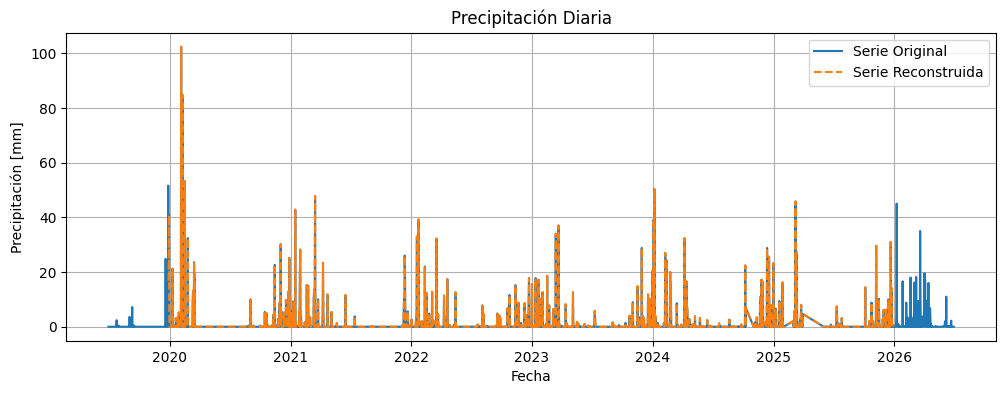

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(datos_precipitacion_completo["Fecha"], datos_precipitacion_completo["Precipitacion"], label = "Serie Original")
plt.plot(datos_precipitacion_completo["Fecha"], serie_reconstruida, label = "Serie Reconstruida", linestyle="--")

plt.xlabel("Fecha")
plt.ylabel("Precipitación [mm]")
plt.title("Precipitación Diaria")
plt.legend()
plt.grid()
plt.show();

## Comparación de resultados de Descomposición

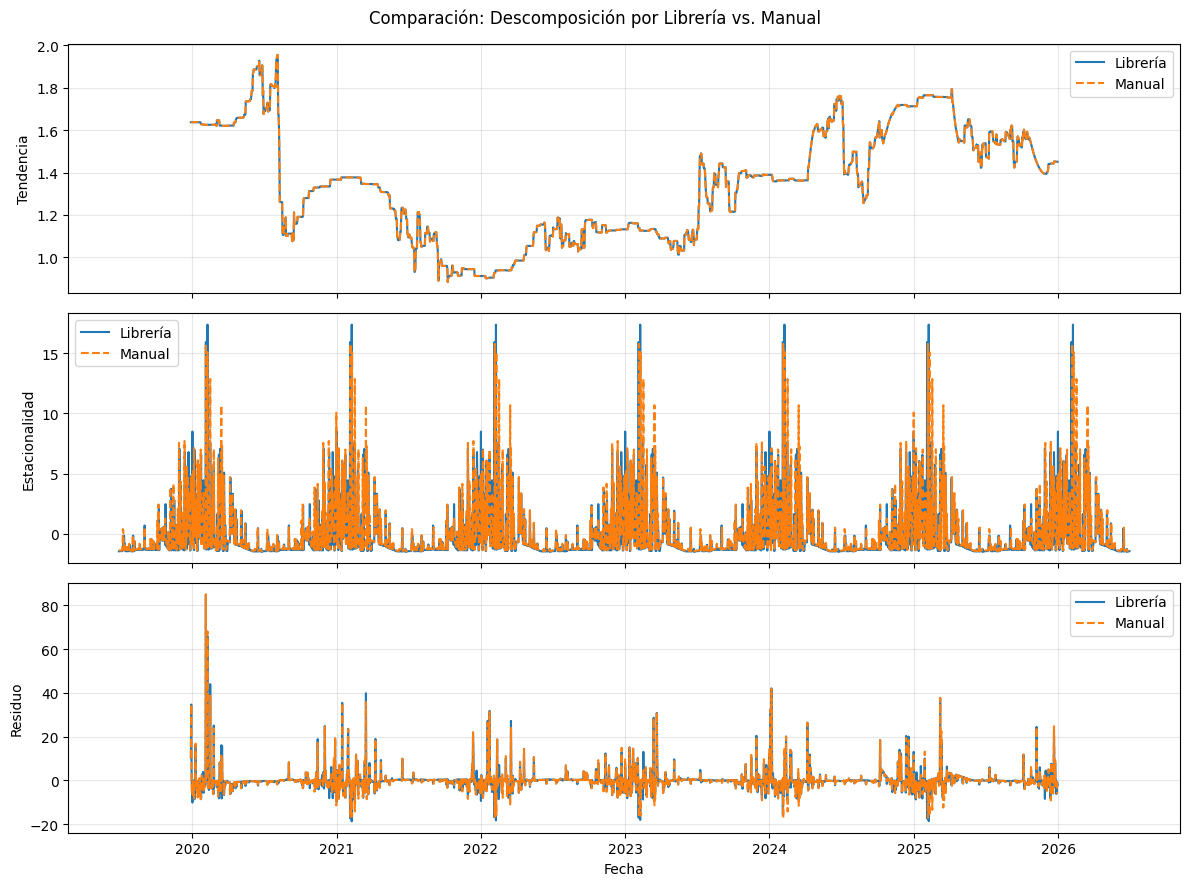

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# --- Tendencia ---
axes[0].plot(datos_precipitacion_completo["Fecha"], tendencia_libreria, label = "Librería")
axes[0].plot(datos_precipitacion_completo["Fecha"], tendencia, label = "Manual", linestyle="--")
axes[0].set_ylabel("Tendencia")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Estacionalidad ---
axes[1].plot(datos_precipitacion_completo["Fecha"], estacionalidad_libreria, label = "Librería")
axes[1].plot(datos_precipitacion_completo["Fecha"], datos_precipitacion_completo["Estacionalidad"], label = "Manual", linestyle="--")
axes[1].set_ylabel("Estacionalidad")
axes[1].legend()
axes[1].grid(alpha=0.3)

# --- Residuo ---
axes[2].plot(datos_precipitacion_completo["Fecha"], residuo_libreria, label = "Librería")
axes[2].plot(datos_precipitacion_completo["Fecha"], residuo, label = "Manual", linestyle="--")
axes[2].set_ylabel("Residuo")
axes[2].set_xlabel("Fecha")
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle("Comparación: Descomposición por Librería vs. Manual")
plt.tight_layout()
plt.show()